# YOLO26n-seg — Conjunctiva Segmentation Training

**Project** : AnedetSegmentor — Phase 1 (Segmentation)  
**Model**   : `yolo26n-seg` (1 class: `conjunctiva`)  
**Dataset** : Roboflow export — `train/` `valid/` `test/` flat layout  
**Target**  : Export **TFLite FP16** (primary Android) + **ONNX FP32** (parity/debug)

> **Note on ExecuTorch:** Ultralytics 8.4.x + YOLO26 triggers a `KeyError: 'feats'`  
> during ExecuTorch dry-run export. This is a known incompatibility between  
> YOLO26's decoupled dict-output head and `torch.export.export()`.  
> **TFLite FP16** is the stable equivalent for Android — same GPU delegate  
> path already used in AnedetApp, no extra runtime needed.

---
| # | Section |
|---|---|
| 1 | Environment Setup & Verification |
| 2 | Dataset Inspection & Validation |
| 3 | Patch data.yaml for working dir |
| 4 | Training YOLO26n-seg |
| 5 | Evaluation & Metrics |
| 6 | Export (TFLite FP16 + ONNX FP32) |
| 7 | Parity Testing |
| 8 | Artifact Summary |

## 1. Environment Setup & Verification

In [27]:
# ── Install / upgrade ─────────────────────────────────────────────────────────
!pip install -U onnx2tf onnxslim --quiet
!pip install -U ultralytics --quiet
!pip install onnx onnxruntime --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 4.3 MB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 84.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 98.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 38.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 80.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 82.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 81.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 k

In [2]:
import os, shutil, yaml, time, warnings
from pathlib import Path

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings('ignore')

# ── Env check ─────────────────────────────────────────────────────────────────
print(f"PyTorch    : {torch.__version__}")
print(f"CUDA avail : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}    : {torch.cuda.get_device_name(i)}  "
              f"({torch.cuda.get_device_properties(i).total_memory / 1e9:.1f} GB)")

import ultralytics
print(f"Ultralytics: {ultralytics.__version__}")
ultralytics.checks()

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (4 CPUs, 31.4 GB RAM, 6960.4/8062.4 GB disk)


In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
DATASET_ROOT = Path("/kaggle/input/datasets/sparkplugx1904/"
                    "conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2")
WORK_DIR   = Path("/kaggle/working")
EXPORT_DIR = WORK_DIR / "exports" / "conj-seg-yolo26n"
RUN_NAME   = "train-conj26n-seg"

EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# Auto-select device
if torch.cuda.device_count() > 1:
    DEVICE = "0,1"
elif torch.cuda.is_available():
    DEVICE = "0"
else:
    DEVICE = "cpu"

print(f"Dataset root : {DATASET_ROOT}")
print(f"Working dir  : {WORK_DIR}")
print(f"Export dir   : {EXPORT_DIR}")
print(f"Device       : {DEVICE}")
print()
print("Dataset contents:")
for p in sorted(DATASET_ROOT.iterdir()):
    print(f"  {'/' if p.is_dir() else ' '} {p.name}")

Dataset root : /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2
Working dir  : /kaggle/working
Export dir   : /kaggle/working/exports/conj-seg-yolo26n
Device       : 0,1

Dataset contents:
    README.dataset.txt
    README.roboflow.txt
    data.yaml
  / test
  / train
  / valid


## 2. Dataset Inspection & Validation

In [4]:
# ── Inspect original data.yaml ────────────────────────────────────────────────
orig_yaml = DATASET_ROOT / 'data.yaml'
print(f"── {orig_yaml} ──")
print(orig_yaml.read_text())

── /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/data.yaml ──
names:
- conjunctiva
nc: 1
roboflow:
  license: Public Domain
  project: eye-conjunctiva-detector-kwkjn
  url: https://universe.roboflow.com/conjuctiva-0ycvu/eye-conjunctiva-detector-kwkjn/dataset/2
  version: 2
  workspace: conjuctiva-0ycvu
test: ../test/images
train: ../train/images
val: ../valid/images



In [5]:
# ── Count images & labels per split ──────────────────────────────────────────
SPLIT_DIRS = {
    'train': DATASET_ROOT / 'train',
    'valid': DATASET_ROOT / 'valid',
    'test' : DATASET_ROOT / 'test',
}

stats = {}
for split, split_dir in SPLIT_DIRS.items():
    img_dir = split_dir / 'images'
    lbl_dir = split_dir / 'labels'
    imgs   = (list(img_dir.glob('*.jpg')) + list(img_dir.glob('*.png'))) if img_dir.exists() else []
    labels = list(lbl_dir.glob('*.txt')) if lbl_dir.exists() else []
    stats[split] = {'images': len(imgs), 'labels': len(labels),
                    'img_dir': img_dir, 'lbl_dir': lbl_dir}
    ok = '✅' if abs(len(imgs) - len(labels)) == 0 else '⚠️ '
    print(f"{ok} [{split:5s}]  images={len(imgs):4d}  labels={len(labels):4d}  "
          f"img_dir={img_dir.exists()}  lbl_dir={lbl_dir.exists()}")

print(f"\n   Total images : {sum(s['images'] for s in stats.values())}")

✅ [train]  images= 588  labels= 588  img_dir=True  lbl_dir=True
✅ [valid]  images= 108  labels= 108  img_dir=True  lbl_dir=True
✅ [test ]  images=  66  labels=  66  img_dir=True  lbl_dir=True

   Total images : 762


In [6]:
# ── Label format sanity check ─────────────────────────────────────────────────
errors = []
for split, s in stats.items():
    for lbl in s['lbl_dir'].glob('*.txt'):
        with open(lbl) as f:
            for i, line in enumerate(f, 1):
                line = line.strip()
                if not line: continue
                parts = line.split()
                if len(parts) < 7:
                    errors.append(f"[{split}] {lbl.name} L{i}: only {len(parts)} tokens")
                elif (len(parts) - 1) % 2 != 0:
                    errors.append(f"[{split}] {lbl.name} L{i}: odd coord count")

if errors:
    print(f"⚠️  {len(errors)} issue(s):")
    for e in errors[:20]: print(f"   {e}")
else:
    print("✅ All labels pass format check")

✅ All labels pass format check


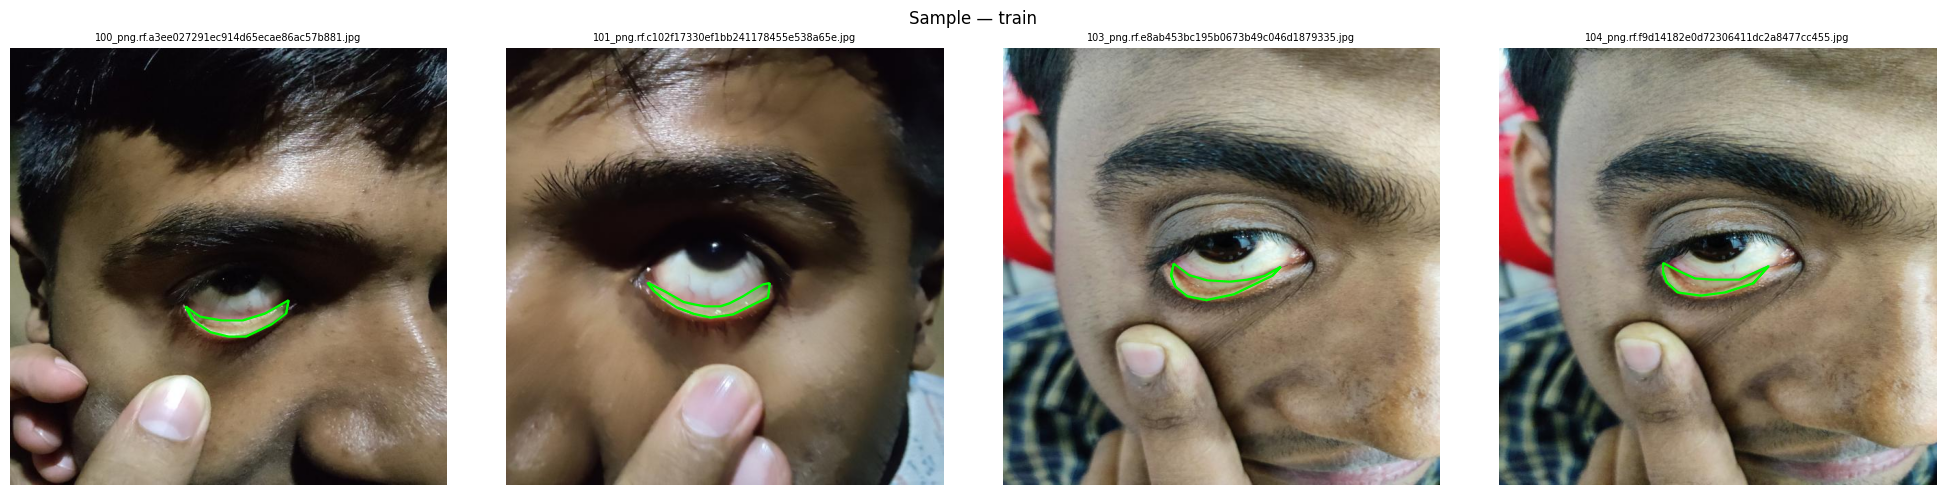

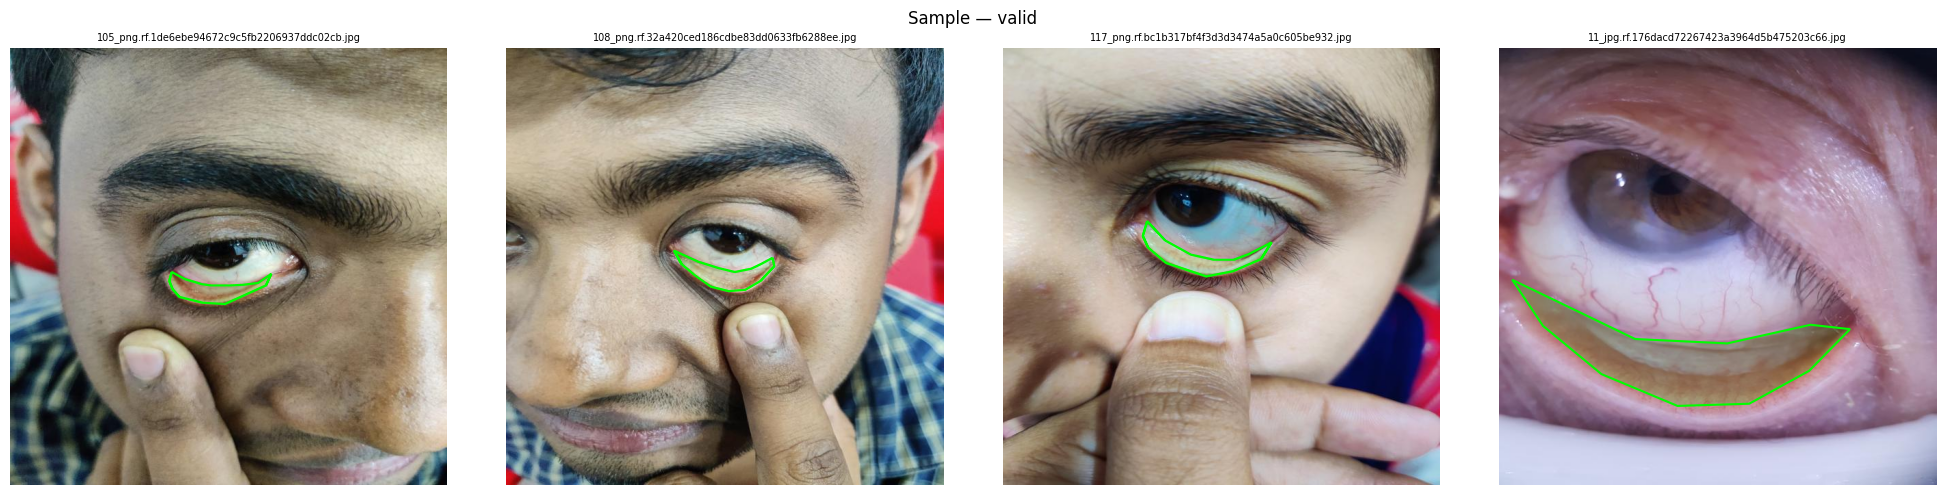

In [7]:
# ── Visualise samples with polygon overlays ───────────────────────────────────
def visualise_samples(split='train', n=4):
    img_dir = stats[split]['img_dir']
    lbl_dir = stats[split]['lbl_dir']
    imgs = sorted(img_dir.glob('*.jpg'))[:n] or sorted(img_dir.glob('*.png'))[:n]
    if not imgs:
        print(f"No images in {img_dir}"); return

    fig, axes = plt.subplots(1, len(imgs), figsize=(5 * len(imgs), 5))
    if len(imgs) == 1: axes = [axes]

    for ax, img_path in zip(axes, imgs):
        img = np.array(Image.open(img_path).convert('RGB'))
        h, w = img.shape[:2]
        ax.imshow(img)
        lbl_path = lbl_dir / (img_path.stem + '.txt')
        if lbl_path.exists():
            for line in open(lbl_path):
                line = line.strip()
                if not line: continue
                parts = list(map(float, line.split()))
                pts = np.array(parts[1:]).reshape(-1, 2)
                pts[:, 0] *= w; pts[:, 1] *= h
                ax.add_patch(mpatches.Polygon(pts, closed=True,
                    fill=True, facecolor=(0,1,0,0.15), edgecolor='lime', lw=1.5))
        ax.set_title(img_path.name, fontsize=7)
        ax.axis('off')

    plt.suptitle(f'Sample — {split}', fontsize=12)
    plt.tight_layout()
    plt.savefig(WORK_DIR / f'samples_{split}.png', dpi=120, bbox_inches='tight')
    plt.show()

visualise_samples('train', n=4)
visualise_samples('valid', n=4)

## 3. Patch data.yaml

Roboflow's `data.yaml` uses relative paths (`../train/images`).  
We write a patched copy in `/kaggle/working` with absolute `path:` so  
YOLO can locate the read-only input without copying the dataset.

In [8]:
with open(DATASET_ROOT / 'data.yaml') as f:
    orig_cfg = yaml.safe_load(f)

patched_cfg = {
    'path' : str(DATASET_ROOT),
    'train': 'train/images',
    'val'  : 'valid/images',
    'test' : 'test/images',
    'nc'   : orig_cfg.get('nc', 1),
    'names': orig_cfg.get('names', ['conjunctiva']),
}

data_yaml_path = WORK_DIR / 'data.yaml'
with open(data_yaml_path, 'w') as f:
    yaml.dump(patched_cfg, f, default_flow_style=False, sort_keys=False)

print(f"Patched data.yaml → {data_yaml_path}")
print()
print(open(data_yaml_path).read())

Patched data.yaml → /kaggle/working/data.yaml

path: /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2
train: train/images
val: valid/images
test: test/images
nc: 1
names:
- conjunctiva



In [9]:
# ── Sanity check: all split dirs resolvable & non-empty ───────────────────────
for key in ('train', 'val', 'test'):
    p = DATASET_ROOT / patched_cfg[key]
    imgs = list(p.glob('*.jpg')) + list(p.glob('*.png'))
    status = '✅' if imgs else '❌ EMPTY'
    print(f"{status}  {key:5s} → {p}  ({len(imgs)} imgs)")

✅  train → /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/train/images  (588 imgs)
✅  val   → /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/valid/images  (108 imgs)
✅  test  → /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/test/images  (66 imgs)


## 4. Training YOLO26n-seg

In [10]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
# VRAM guide:
#   T4  ~15 GB  → BATCH=32 safe
#   2×T4        → BATCH=64
#   P100 ~16 GB → BATCH=32
#   Reduce to 16 if OOM

IMG_SIZE   = 320
BATCH_SIZE = 32    # ← lower to 16 if OOM
EPOCHS     = 200
PATIENCE   = 30

print("Training config")
print(f"  model     : yolo26n-seg")
print(f"  imgsz     : {IMG_SIZE}")
print(f"  batch     : {BATCH_SIZE}")
print(f"  epochs    : {EPOCHS}  (patience={PATIENCE})")
print(f"  device    : {DEVICE}")
print(f"  optimizer : SGD  (MuSGD native in YOLO26)")
print(f"  amp       : True  (server-side only — safe during training)")

Training config
  model     : yolo26n-seg
  imgsz     : 320
  batch     : 32
  epochs    : 200  (patience=30)
  device    : 0,1
  optimizer : SGD  (MuSGD native in YOLO26)
  amp       : True  (server-side only — safe during training)


In [11]:
from ultralytics import YOLO

model = YOLO('yolo26n-seg.pt')
model.info()

YOLO26n-seg summary: 309 layers, 3,126,280 parameters, 0 gradients, 10.5 GFLOPs


(309, 3126280, 0, 10.509952)

In [12]:
results = model.train(
    data         = str(data_yaml_path),
    imgsz        = IMG_SIZE,
    epochs       = EPOCHS,
    batch        = BATCH_SIZE,
    device       = DEVICE,
    optimizer    = 'SGD',
    patience     = PATIENCE,
    amp          = True,
    project      = str(WORK_DIR / 'runs' / 'segment'),
    name         = RUN_NAME,
    exist_ok     = False,
    verbose      = True,
    cache        = True,
    # Augmentation — lightweight, ocular-appropriate
    fliplr       = 0.5,    # horizontal flip (left/right eye symmetry)
    flipud       = 0.0,    # no vertical flip
    degrees      = 10.0,   # rotation ±10°
    scale        = 0.2,    # zoom jitter ±20%
    hsv_v        = 0.4,    # brightness jitter
    hsv_s        = 0.3,    # saturation jitter
    hsv_h        = 0.015,
    mosaic       = 1.0,
    close_mosaic = 10,
    save         = True,
    save_period  = 25,
)

print("\n✅ Training complete")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=10.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.3, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n-seg.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-conj26n-seg,

## 5. Evaluation & Metrics

In [13]:
best_weights = WORK_DIR / 'runs' / 'segment' / RUN_NAME / 'weights' / 'best.pt'
assert best_weights.exists(), f"best.pt not found: {best_weights}"
print(f"Best weights: {best_weights}  ({best_weights.stat().st_size/1e6:.1f} MB)")

best_model = YOLO(str(best_weights))

Best weights: /kaggle/working/runs/segment/train-conj26n-seg/weights/best.pt  (6.5 MB)


In [14]:
val_metrics = best_model.val(
    data    = str(data_yaml_path),
    imgsz   = IMG_SIZE,
    split   = 'val',
    device  = DEVICE,
    verbose = True,
)
print(f"\n── Val ──")
print(f"  Box  mAP50     : {val_metrics.box.map50:.4f}")
print(f"  Box  mAP50-95  : {val_metrics.box.map:.4f}")
print(f"  Mask mAP50     : {val_metrics.seg.map50:.4f}")
print(f"  Mask mAP50-95  : {val_metrics.seg.map:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
YOLO26n-seg summary (fused): 139 layers, 2,689,079 parameters, 0 gradients, 9.0 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 32.2±6.7 MB/s, size: 37.9 KB)
val: Scanning /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/valid/labels... 108 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 108/108 499.7it/s 0.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 3.1it/s 2.3s0.2s
                   all        108        103      0.935      0.974      0.978      0.713      0.935      0.974 

In [15]:
test_metrics = best_model.val(
    data    = str(data_yaml_path),
    imgsz   = IMG_SIZE,
    split   = 'test',
    device  = DEVICE,
    verbose = True,
)
print(f"\n── Test ──")
print(f"  Box  mAP50     : {test_metrics.box.map50:.4f}")
print(f"  Box  mAP50-95  : {test_metrics.box.map:.4f}")
print(f"  Mask mAP50     : {test_metrics.seg.map50:.4f}")
print(f"  Mask mAP50-95  : {test_metrics.seg.map:.4f}")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 2.3±0.1 ms, read: 5.2±1.0 MB/s, size: 37.9 KB)
val: Scanning /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/test/labels... 66 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 66/66 289.9it/s 0.2s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 2.7it/s 1.9s0.6s
                   all         66         63      0.935       0.92      0.964      0.693      0.935       0.92      0.964      0.644
Speed: 0.7ms preprocess, 4.8ms inference, 0.0ms loss, 3.6ms postprocess

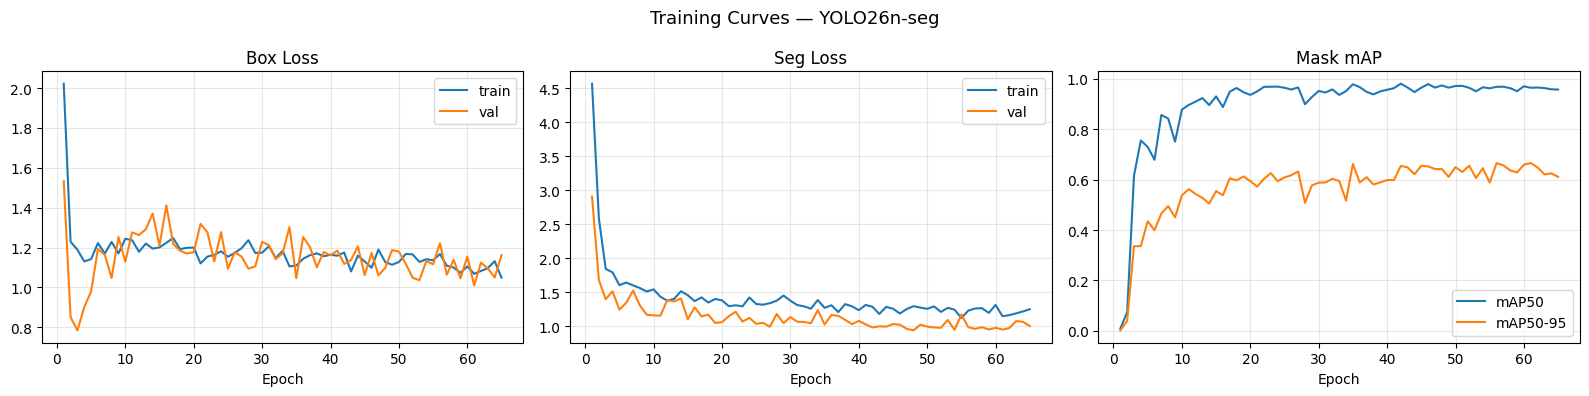

Saved: training_curves.png


In [16]:
# ── Training curves ───────────────────────────────────────────────────────────
import pandas as pd

results_csv = WORK_DIR / 'runs' / 'segment' / RUN_NAME / 'results.csv'
if results_csv.exists():
    df = pd.read_csv(results_csv)
    df.columns = df.columns.str.strip()

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    for col, lbl in [('train/box_loss','train'),('val/box_loss','val')]:
        if col in df.columns: axes[0].plot(df['epoch'], df[col], label=lbl)
    axes[0].set_title('Box Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

    for col, lbl in [('train/seg_loss','train'),('val/seg_loss','val')]:
        if col in df.columns: axes[1].plot(df['epoch'], df[col], label=lbl)
    axes[1].set_title('Seg Loss'); axes[1].legend(); axes[1].grid(alpha=0.3)

    for col, lbl in [('metrics/mAP50(M)','mAP50'),('metrics/mAP50-95(M)','mAP50-95')]:
        if col in df.columns: axes[2].plot(df['epoch'], df[col], label=lbl)
    axes[2].set_title('Mask mAP'); axes[2].legend(); axes[2].grid(alpha=0.3)

    for ax in axes: ax.set_xlabel('Epoch')
    plt.suptitle('Training Curves — YOLO26n-seg', fontsize=13)
    plt.tight_layout()
    plt.savefig(WORK_DIR / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")
else:
    print(f"results.csv not found at {results_csv}")

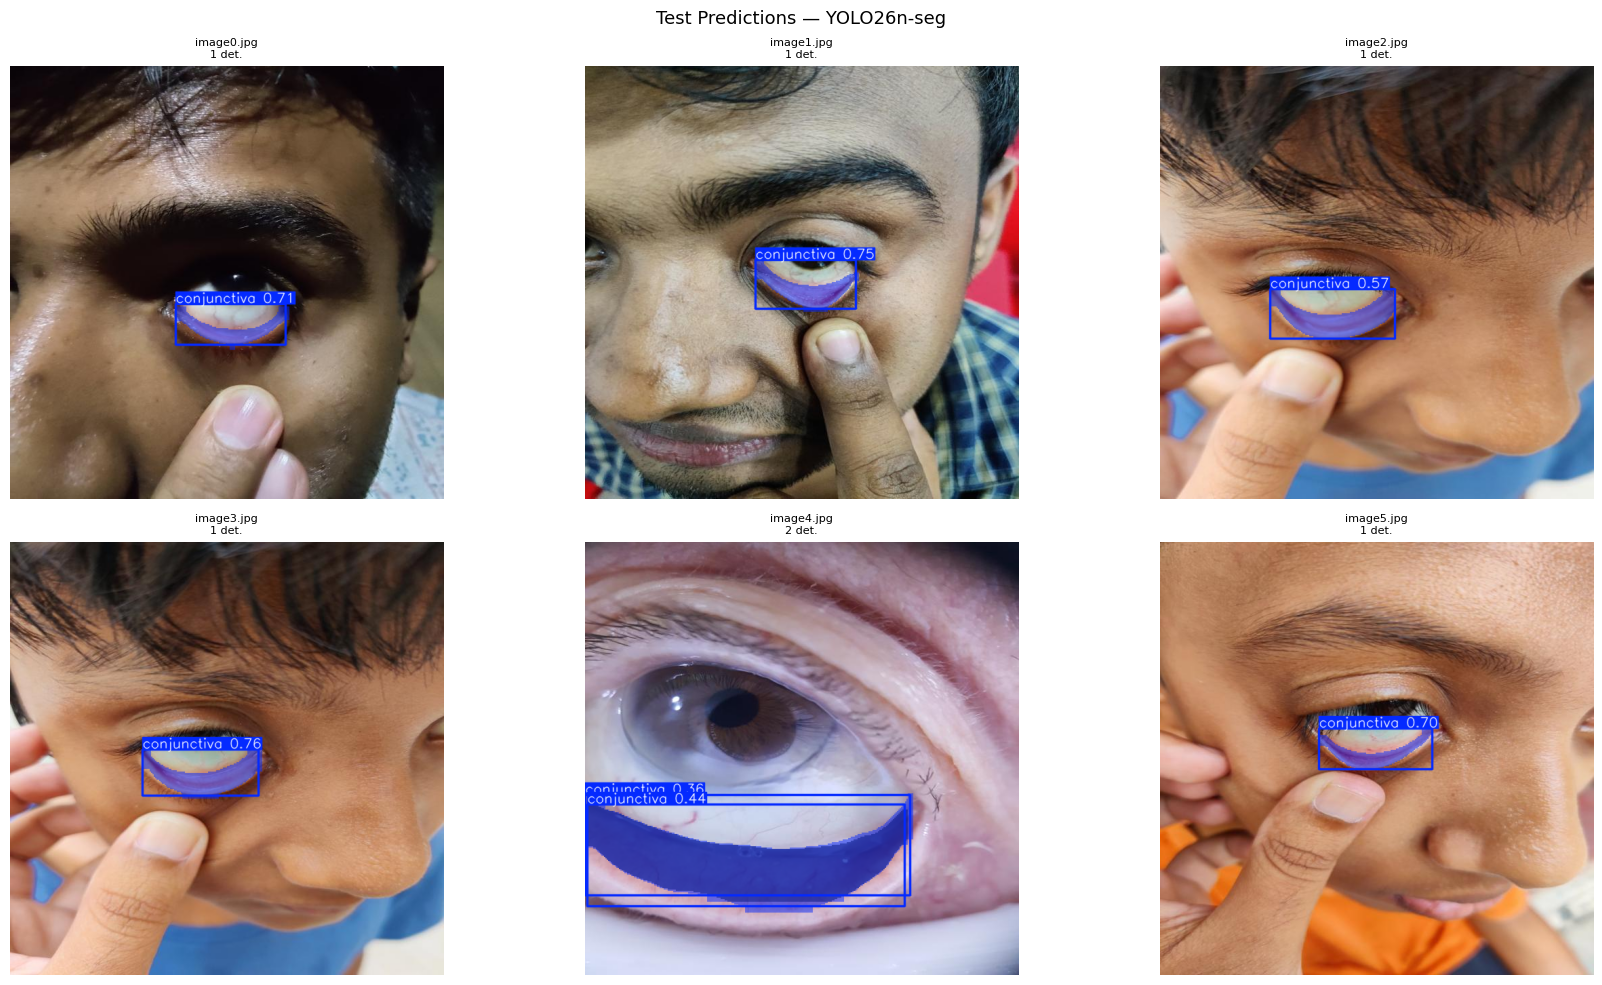

Saved: test_predictions.png


In [20]:
# ── Visual predictions on test samples ───────────────────────────────────────
test_img_dir = DATASET_ROOT / 'test' / 'images'
test_imgs = sorted(test_img_dir.glob('*.jpg'))[:6] or sorted(test_img_dir.glob('*.png'))[:6]

preds = best_model.predict(
    source=test_imgs, imgsz=IMG_SIZE, conf=0.25, iou=0.5,
    device=DEVICE, save=False, verbose=False)

cols = 3
rows = (len(preds) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
axes = np.array(axes).flatten()

for ax, r in zip(axes, preds):
    ax.imshow(r.plot()[..., ::-1])
    n_det = len(r.boxes) if r.boxes is not None else 0
    ax.set_title(f"{Path(r.path).name}\n{n_det} det.", fontsize=8)
    ax.axis('off')
for ax in axes[len(preds):]: ax.set_visible(False)

plt.suptitle('Test Predictions — YOLO26n-seg', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'test_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: test_predictions.png")

## 6. Export

### Why TFLite instead of ExecuTorch

ExecuTorch export crashes with `KeyError: 'feats'` on Ultralytics 8.4.x + YOLO26  
because `torch.export.export()` requires a model that returns plain tensors — but  
YOLO26's decoupled detection head returns a `dict` in inference mode.  
No stable fix exists in 8.4.56 without monkey-patching `head.py`.

**TFLite FP16** is the correct alternative:
- Directly loadable by AnedetApp's existing `TFLite` runtime
- GPU delegate (`CompatibilityList` + `bestOptionsForThisDevice`) already wired in AnedetApp
- `half=True` → FP16 weights (~2× smaller, same GPU delegate path)
- No extra runtime dependency on Android

**Export plan:**
1. `TFLite FP16` — primary Android model  
2. `ONNX FP32` — parity baseline + debugging

### 6a. ONNX FP32 (parity baseline)

In [21]:
onnx_path = best_model.export(
    format   = 'onnx',
    imgsz    = IMG_SIZE,
    opset    = 18,
    dynamic  = True,
    half     = False,
    simplify = True,
    device   = 'cpu',
)

onnx_dst = EXPORT_DIR / 'yolo26n_seg_fp32.onnx'
shutil.copy(onnx_path, onnx_dst)
print(f"✅ ONNX → {onnx_dst}  ({onnx_dst.stat().st_size/1e6:.1f} MB)")

Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/segment/train-conj26n-seg/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) ((1, 300, 38), (1, 32, 80, 80)) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 18...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 5.8s, saved as '/kaggle/working/runs/segment/train-conj26n-seg/weights/best.onnx' (11.4 MB)

Export complete (6.0s)
Results saved to /kaggle/working/runs/segment/train-conj26n-seg/weights/best.onnx
Predict:         yolo predict task=segment model=/kaggle/working/runs/segment/train-conj26n-seg/weights/best.onnx imgsz=320 
Validate:        yolo val task=segment model=/kaggle/working/runs/segment/train-conj26n-seg/weights/best.onnx imgsz=320 data=/kaggle/working/data.yaml  
Visualize:       https://netron.app
✅ ONNX → /kaggle/working/exports/conj-seg-yolo26n/yolo26n_seg_fp32.onnx  (12.0 MB)


### **6b. TFLite FP16 (primary Android target)

In [31]:
# 1. Install ulang versi onnx2tf spesifik yang dibutuhkan agar environment bersih
!pip install -U "onnx2tf>=1.26.3,<1.29.0" onnxslim onnx-graphsurgeon --quiet

# 2. Paksa Python untuk memuat ulang modul onnx2tf yang baru saja di-install
import sys
import importlib

for sys_module in list(sys.modules.keys()):
    if sys_module.startswith("onnx2tf"):
        del sys.modules[sys_module]

import onnx2tf
import onnx2tf.ops.TopK
import builtins
import numpy as np

# 3. Terapkan kembali Advanced Monkey-Patch untuk NumPy 2.x kompatibilitas
class MetaInt(type):
    def __instancecheck__(cls, instance):
        return isinstance(instance, (builtins.int, np.integer))

class SafeInt(metaclass=MetaInt):
    def __new__(cls, *args, **kwargs):
        if args and isinstance(args[0], np.ndarray):
            scalar_val = args[0].item() if args[0].size == 1 else args[0].flatten()[0]
            return builtins.int(scalar_val)
        return builtins.int(*args, **kwargs)

onnx2tf.ops.TopK.int = SafeInt

print("✅ Environment disegarkan, onnx2tf v1.28.8 berhasil dimuat, dan monkey-patch aktif!")

✅ Environment disegarkan, onnx2tf v1.28.8 berhasil dimuat, dan monkey-patch aktif!


In [32]:
# TFLite export requires tensorflow — install if missing
try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__} already installed")
except ImportError:
    print("Installing tensorflow...")
    !pip install tensorflow --quiet

# ── Export TFLite FP16 ────────────────────────────────────────────────────────
# half=True  → FP16 weights (2× smaller, runs via GPU delegate on Android)
# int8=False → skip INT8 quantisation (needs calibration dataset)
tflite_path = best_model.export(
    format  = 'tflite',
    imgsz   = IMG_SIZE,
    half    = True,     # FP16 — GPU delegate path in AnedetApp
    int8    = False,
    device  = 'cpu',    # export always on CPU
)

tflite_dst = EXPORT_DIR / 'yolo26n_seg_fp16.tflite'
shutil.copy(tflite_path, tflite_dst)
print(f"\n✅ TFLite FP16 → {tflite_dst}  ({tflite_dst.stat().st_size/1e6:.1f} MB)")

TensorFlow 2.19.0 already installed
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)

PyTorch: starting from '/kaggle/working/runs/segment/train-conj26n-seg/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) ((1, 300, 38), (1, 32, 80, 80)) (6.2 MB)

ONNX: starting export with onnx 1.21.0 opset 20...
ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.1s, saved as '/kaggle/working/runs/segment/train-conj26n-seg/weights/best.onnx' (10.5 MB)

TensorFlow SavedModel: starting export with tensorflow 2.19.0...
TensorFlow SavedModel: starting TFLite export with onnx2tf 1.28.8...


I0000 00:00:1780033901.936547      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13175 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780033901.941894      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1780033906.012420      58 cuda_dnn.cc:529] Loaded cuDNN version 91002


Saved artifact at '/kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model'. The following endpoints are available:

* Endpoint 'serving_default'
  inputs_0 (POSITIONAL_ONLY): TensorSpec(shape=(1, 320, 320, 3), dtype=tf.float32, name='images')
Output Type:
  List[TensorSpec(shape=(1, 300, 38), dtype=tf.float32, name=None), TensorSpec(shape=(1, 80, 80, 32), dtype=tf.float32, name=None)]
Captures:
  139460416705680: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  139460416704528: TensorSpec(shape=(3, 3, 3, 16), dtype=tf.float32, name=None)
  139460416704912: TensorSpec(shape=(16,), dtype=tf.float32, name=None)
  139460416710672: TensorSpec(shape=(4, 2), dtype=tf.int32, name=None)
  139460511298576: TensorSpec(shape=(3, 3, 16, 32), dtype=tf.float32, name=None)
  139460416709136: TensorSpec(shape=(32,), dtype=tf.float32, name=None)
  139460416710864: TensorSpec(shape=(1, 1, 32, 32), dtype=tf.float32, name=None)
  139460416711056: TensorSpec(shape=(32,), dtype=tf.float

I0000 00:00:1780033927.028633      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1780033927.028808      58 single_machine.cc:374] Starting new session
I0000 00:00:1780033927.042362      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13175 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1780033927.043759      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
W0000 00:00:1780033928.852152      58 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1780033928.852192      58 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
I0000 00:00:1780033930.011132      58 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 2
I0000 00:00:1780033930.011

TensorFlow SavedModel: export success ✅ 33.0s, saved as '/kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model' (26.7 MB)

TensorFlow Lite: starting export with tensorflow 2.19.0...
TensorFlow Lite: export success ✅ 0.0s, saved as '/kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model/best_float16.tflite' (5.5 MB)

Export complete (33.2s)
Results saved to /kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model/best_float16.tflite
Predict:         yolo predict task=segment model=/kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model/best_float16.tflite imgsz=320 half
Validate:        yolo val task=segment model=/kaggle/working/runs/segment/train-conj26n-seg/weights/best_saved_model/best_float16.tflite imgsz=320 data=/kaggle/working/data.yaml half 
Visualize:       https://netron.app

✅ TFLite FP16 → /kaggle/working/exports/conj-seg-yolo26n/yolo26n_seg_fp16.tflite  (5.7 MB)


### 6c. metadata.yaml

In [33]:
metadata = {
    'model'             : 'yolo26n-seg',
    'task'              : 'segment',
    'imgsz'             : IMG_SIZE,
    'nc'                : 1,
    'names'             : ['conjunctiva'],
    'primary_format'    : 'tflite',
    'precision'         : 'fp16',
    'android_delegate'  : 'GPU (CompatibilityList + bestOptionsForThisDevice)',
    'nms_free'          : True,
    'nms_coord_format'  : 'x1y1x2y2',
    'proto_space'       : 'global_image',  # imgX = px/protoW * origW
    'executorch_note'   : 'Blocked by KeyError feats in Ultralytics 8.4.x + YOLO26',
    'val_box_mAP50'     : round(float(val_metrics.box.map50),  4),
    'val_mask_mAP50'    : round(float(val_metrics.seg.map50),  4),
    'val_mask_mAP5095'  : round(float(val_metrics.seg.map),    4),
    'test_mask_mAP50'   : round(float(test_metrics.seg.map50), 4),
    'test_mask_mAP5095' : round(float(test_metrics.seg.map),   4),
}

meta_path = EXPORT_DIR / 'metadata.yaml'
with open(meta_path, 'w') as f:
    yaml.dump(metadata, f, default_flow_style=False, sort_keys=False)

print(f"Metadata → {meta_path}")
print()
print(open(meta_path).read())

Metadata → /kaggle/working/exports/conj-seg-yolo26n/metadata.yaml

model: yolo26n-seg
task: segment
imgsz: 320
nc: 1
names:
- conjunctiva
primary_format: tflite
precision: fp16
android_delegate: GPU (CompatibilityList + bestOptionsForThisDevice)
nms_free: true
nms_coord_format: x1y1x2y2
proto_space: global_image
executorch_note: Blocked by KeyError feats in Ultralytics 8.4.x + YOLO26
val_box_mAP50: 0.9776
val_mask_mAP50: 0.9776
val_mask_mAP5095: 0.6583
test_mask_mAP50: 0.9644
test_mask_mAP5095: 0.6444



## 7. Parity Testing — PyTorch vs ONNX

TFLite on-device parity verified during Android integration.  
Here we use ONNX FP32 as a proxy: if ONNX delta ≤ 0.5%, the model export is clean.

In [34]:
import onnxruntime as ort
from ultralytics import YOLO
print(f"ONNXRuntime: {ort.__version__}")

# Solusi: Berikan argumen task='segment' secara eksplisit
onnx_model = YOLO(str(onnx_dst), task='segment') 

onnx_val = onnx_model.val(
    data=str(data_yaml_path), 
    imgsz=IMG_SIZE,
    split='val', 
    device='cpu', 
    verbose=False,
    task='segment' # Memastikan pipeline validasi menghitung metrik Mask
)

pt_map   = float(val_metrics.seg.map50)
onnx_map = float(onnx_val.seg.map50) # Sekarang .seg sudah tersedia!
delta    = abs(pt_map - onnx_map)
TOLS     = 0.005

print(f"\n── Parity Report (Val Mask mAP50) ──")
print(f"  PyTorch .pt   : {pt_map:.4f}")
print(f"  ONNX FP32     : {onnx_map:.4f}")
print(f"  Δ             : {delta:.4f}")
print(f"  Tolerance     : ≤ {TOLS*100:.1f}%")
if delta <= TOLS:
    print("  ✅ PASS — export is clean")
else:
    print("  ⚠️ FAIL — inspect opset / simplify settings")

ONNXRuntime: 1.26.0
Ultralytics 8.4.56 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading /kaggle/working/exports/conj-seg-yolo26n/yolo26n_seg_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider
val: Fast image access ✅ (ping: 1.7±0.1 ms, read: 27.9±8.3 MB/s, size: 37.4 KB)
val: Scanning /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/valid/labels... 108 images, 5 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 108/108 482.6it/s 0.2s1s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/sparkplugx1904/conjunctiva-detection-yolo26s-seg/eye-conjunctiva-detector-2/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.5it/s 4.6s0.7ss
                   all        108        103      0.935      0.974      0.978      0.713      0.935      0

Loading /kaggle/working/exports/conj-seg-yolo26n/yolo26n_seg_fp32.onnx for ONNX Runtime inference...
Using ONNX Runtime 1.26.0 with CPUExecutionProvider


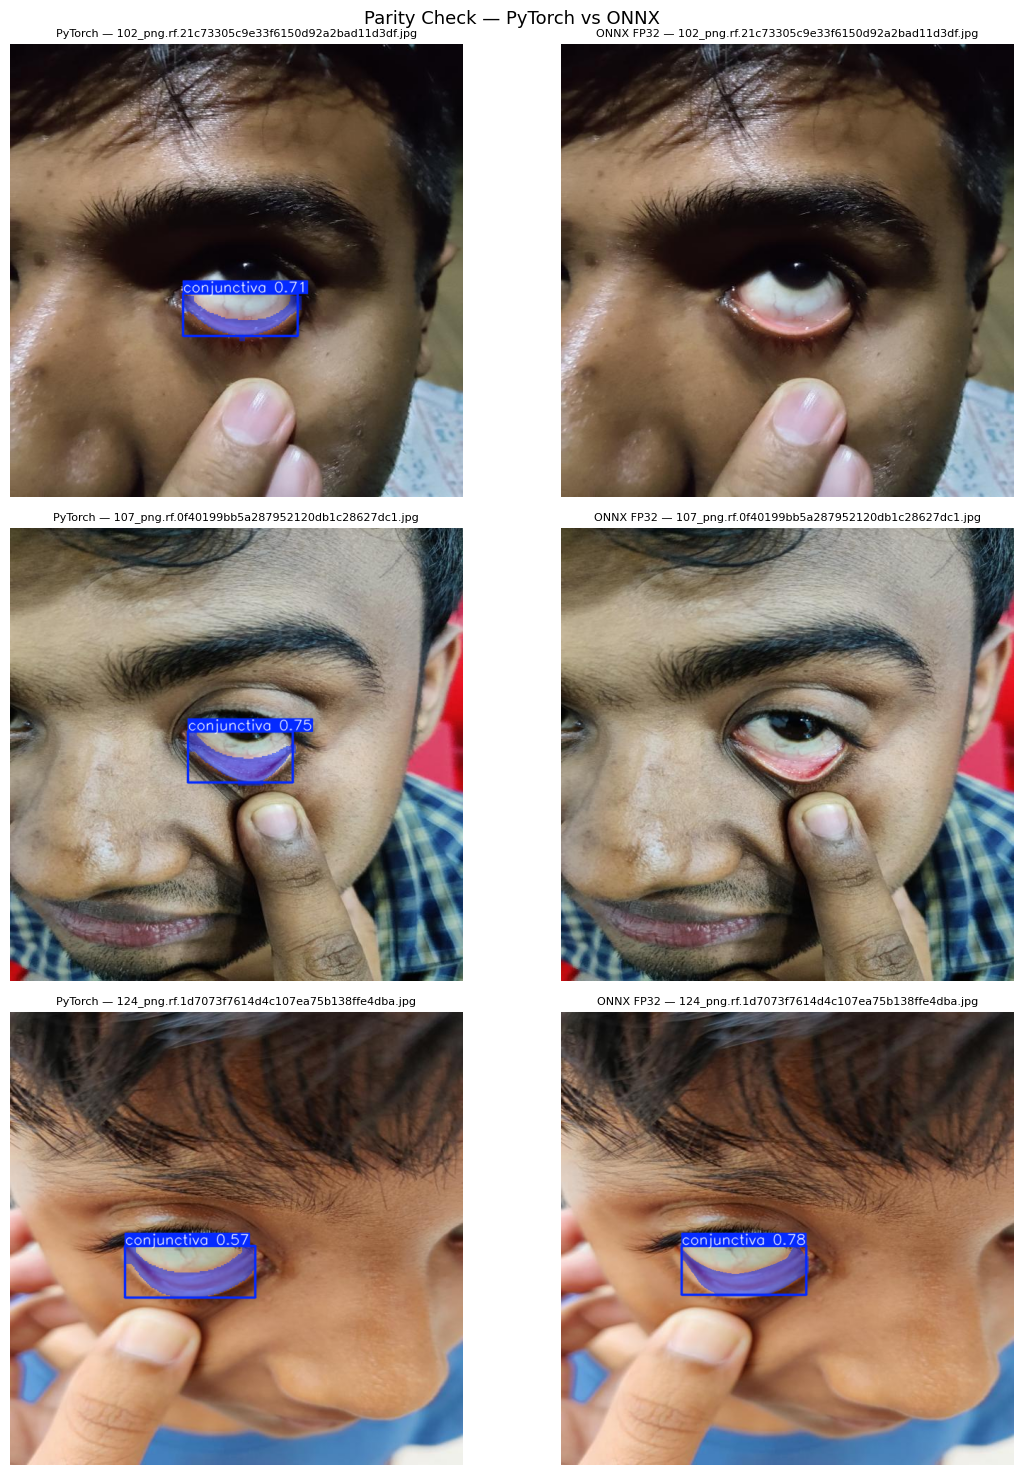

Saved: parity_visual.png


In [35]:
# ── Side-by-side visual parity ────────────────────────────────────────────────
sample_imgs = sorted((DATASET_ROOT / 'test' / 'images').glob('*.jpg'))[:3] or \
              sorted((DATASET_ROOT / 'test' / 'images').glob('*.png'))[:3]

fig, axes = plt.subplots(len(sample_imgs), 2,
                         figsize=(12, 5 * len(sample_imgs)))
if len(sample_imgs) == 1: axes = [axes]

for row, img_path in enumerate(sample_imgs):
    pt_r   = best_model.predict(str(img_path), conf=0.25, device=DEVICE, verbose=False)[0]
    onnx_r = onnx_model.predict(str(img_path), conf=0.25, device='cpu',  verbose=False)[0]

    axes[row][0].imshow(pt_r.plot()[..., ::-1])
    axes[row][0].set_title(f'PyTorch — {img_path.name}', fontsize=8)
    axes[row][0].axis('off')

    axes[row][1].imshow(onnx_r.plot()[..., ::-1])
    axes[row][1].set_title(f'ONNX FP32 — {img_path.name}', fontsize=8)
    axes[row][1].axis('off')

plt.suptitle('Parity Check — PyTorch vs ONNX', fontsize=13)
plt.tight_layout()
plt.savefig(WORK_DIR / 'parity_visual.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: parity_visual.png")

## 8. Artifact Summary

In [36]:
print("=" * 65)
print("  TRAINING COMPLETE — Artifact Summary")
print("=" * 65)

artifacts = [
    ('Best weights (.pt)',        best_weights),
    ('TFLite FP16 (.tflite)',     tflite_dst),
    ('ONNX FP32 (.onnx)',         onnx_dst),
    ('Metadata (.yaml)',          meta_path),
    ('Training curves',           WORK_DIR / 'training_curves.png'),
    ('Test predictions',          WORK_DIR / 'test_predictions.png'),
    ('Parity visual',             WORK_DIR / 'parity_visual.png'),
]

for label, path in artifacts:
    path = Path(path)
    if path.exists():
        mb = path.stat().st_size / 1e6
        print(f"  ✅  {label:<28}  {path.name:<44}  {mb:6.2f} MB")
    else:
        print(f"  ⚠️   {label:<28}  NOT FOUND — {path}")

print()
print("── Metrics ──")
print(f"  Val  Mask mAP50    : {val_metrics.seg.map50:.4f}")
print(f"  Val  Mask mAP50-95 : {val_metrics.seg.map:.4f}")
print(f"  Test Mask mAP50    : {test_metrics.seg.map50:.4f}")
print(f"  Test Mask mAP50-95 : {test_metrics.seg.map:.4f}")
print()
print("── Android integration (AnedetApp) ──")
print("  1. Copy yolo26n_seg_fp16.tflite → app/src/main/assets/models/")
print("  2. Update model path in AnedetSegmentor TFLite loader")
print("  3. GPU delegate: CompatibilityList + bestOptionsForThisDevice + setPrecisionLossAllowed")
print("  4. Run train_yolo26m_cls_conjunctiva.ipynb for the classifier")
print("=" * 65)

  TRAINING COMPLETE — Artifact Summary
  ✅  Best weights (.pt)            best.pt                                         6.50 MB
  ✅  TFLite FP16 (.tflite)         yolo26n_seg_fp16.tflite                         5.72 MB
  ✅  ONNX FP32 (.onnx)             yolo26n_seg_fp32.onnx                          12.01 MB
  ✅  Metadata (.yaml)              metadata.yaml                                   0.00 MB
  ✅  Training curves               training_curves.png                             0.15 MB
  ✅  Test predictions              test_predictions.png                            3.10 MB
  ✅  Parity visual                 parity_visual.png                               1.91 MB

── Metrics ──
  Val  Mask mAP50    : 0.9776
  Val  Mask mAP50-95 : 0.6583
  Test Mask mAP50    : 0.9644
  Test Mask mAP50-95 : 0.6444

── Android integration (AnedetApp) ──
  1. Copy yolo26n_seg_fp16.tflite → app/src/main/assets/models/
  2. Update model path in AnedetSegmentor TFLite loader
  3. GPU delegate: Compatibili